# Homework 6 — Fourier Transform and Spectrogram Clustering of ESC-50 Sounds

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

A raw waveform is a poor description of a sound: two recordings of the same bird are completely different sequences of samples. The Fourier transform moves the signal into the frequency domain, where the same bird becomes the same pattern. Here the short-time FFT turns 80 clips of `dog` and `chirping_birds` into spectrograms, pooling compresses them into feature vectors, and spectral clustering is asked to separate the two sources without ever seeing the labels.

In [1]:
# Environment setup & imports
import pathlib
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import SpectralClustering
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 85})
RANDOM_STATE = 42

## Step 1: Load the `dog` and `chirping_birds` Subset

ESC-50 is a 600 MB archive of 2000 clips in 50 categories, but this task needs only two of them. The metadata file is read directly from the repository and the 80 relevant WAV files are fetched individually — about 35 MB instead of 600 — into a local folder that acts as a cache, so a second run downloads nothing. The same cell works unchanged in Colab.

In [2]:
REPOSITORY = "https://raw.githubusercontent.com/karoldvl/ESC-50/master"
CATEGORIES = ["dog", "chirping_birds"]
AUDIO_DIR = pathlib.Path("esc50_audio")
AUDIO_DIR.mkdir(exist_ok=True)

meta = pd.read_csv(f"{REPOSITORY}/meta/esc50.csv")
subset = meta[meta["category"].isin(CATEGORIES)].sort_values("filename").reset_index(drop=True)

downloaded = 0
for filename in subset["filename"]:
    destination = AUDIO_DIR / filename
    if not destination.exists():
        urllib.request.urlretrieve(f"{REPOSITORY}/audio/{filename}", destination)
        downloaded += 1

print(f"Full dataset: {len(meta)} clips in {meta['category'].nunique()} categories")
print(f"Selected:     {len(subset)} clips ({downloaded} newly downloaded, rest from cache)")
print(subset["category"].value_counts().to_string())

Full dataset: 2000 clips in 50 categories
Selected:     80 clips (0 newly downloaded, rest from cache)
category
dog               40
chirping_birds    40


In [3]:
signals = []
for filename in subset["filename"]:
    sample_rate, samples = wavfile.read(AUDIO_DIR / filename)
    signals.append(samples.astype(np.float64) / 32768.0)  # int16 -> [-1, 1]

y_true = (subset["category"] == "chirping_birds").astype(int).to_numpy()
class_names = ["dog", "chirping_birds"]

print(f"Sample rate: {sample_rate} Hz")
print(f"Clip length: {len(signals[0])} samples = {len(signals[0]) / sample_rate:.1f} s")
print(f"Nyquist frequency: {sample_rate // 2} Hz")

Sample rate: 44100 Hz
Clip length: 220500 samples = 5.0 s
Nyquist frequency: 22050 Hz


In the time domain the two classes are hard to tell apart — both are bursts of activity separated by silence. Whatever distinguishes a bark from a chirp is in *how fast* the pressure oscillates, which is what the Fourier transform measures.

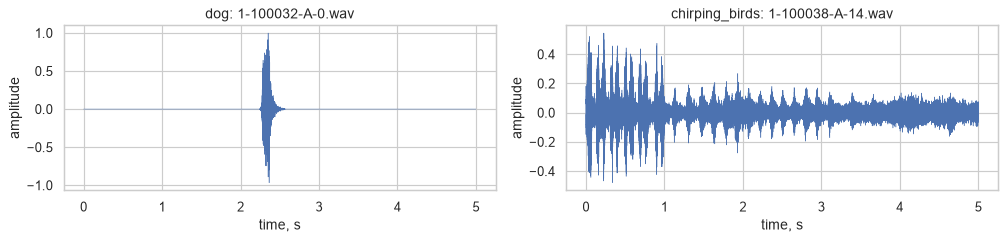

In [4]:
examples = {"dog": int(np.flatnonzero(y_true == 0)[0]), "chirping_birds": int(np.flatnonzero(y_true == 1)[0])}

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
time = np.arange(len(signals[0])) / sample_rate
for ax, (name, index) in zip(axes, examples.items()):
    ax.plot(time, signals[index], linewidth=0.4)
    ax.set(title=f"{name}: {subset['filename'][index]}", xlabel="time, s", ylabel="amplitude")
plt.tight_layout()
plt.show()

## Step 2: The Spectrogram

A single FFT over the whole clip would give the frequencies present somewhere in five seconds, losing all timing. The short-time Fourier transform instead slides a window along the signal and transforms each frame separately:

$$X[k, m] = \sum_{n=0}^{N-1} w[n] \, x[n + m \cdot H] \, e^{-2\pi i k n / N}$$

with a frame of $N = 1024$ samples (23 ms at 44.1 kHz) and a hop of $H = 512$. The Hann window $w[n]$ tapers each frame to zero at the edges, which prevents the discontinuity at the frame boundary from smearing energy across all frequencies. `np.fft.rfft` is used because a real signal has a symmetric spectrum, so only $N/2 + 1$ bins carry information.

In [5]:
def spectrogram(signal, frame_size=1024, hop=512):
    """Magnitude of the short-time Fourier transform, shaped (frequency, time)."""
    n_frames = 1 + (len(signal) - frame_size) // hop
    offsets = hop * np.arange(n_frames)[:, None]
    frames = signal[offsets + np.arange(frame_size)[None, :]] * np.hanning(frame_size)
    return np.abs(np.fft.rfft(frames, axis=1)).T


example_spectrogram = spectrogram(signals[examples["dog"]])
frequencies = np.fft.rfftfreq(1024, 1 / sample_rate)

print(f"Waveform:    {signals[0].shape} samples")
print(f"Spectrogram: {example_spectrogram.shape} = (frequency bins, time frames)")
print(f"Frequency resolution: {frequencies[1]:.1f} Hz per bin")
print(f"Time resolution:      {512 / sample_rate * 1000:.1f} ms per frame")

Waveform:    (220500,) samples
Spectrogram: (513, 429) = (frequency bins, time frames)
Frequency resolution: 43.1 Hz per bin
Time resolution:      11.6 ms per frame


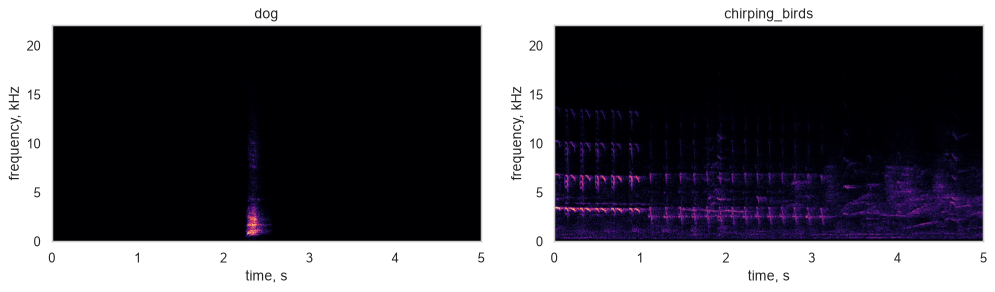

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (name, index) in zip(axes, examples.items()):
    spectrum = np.log1p(spectrogram(signals[index]))
    ax.imshow(spectrum, origin="lower", aspect="auto", cmap="magma",
              extent=[0, 5, 0, sample_rate / 2000])
    ax.set(title=f"{name}", xlabel="time, s", ylabel="frequency, kHz")
    ax.grid(False)
plt.tight_layout()
plt.show()

The difference the waveforms hid is now obvious: the dog's energy sits in a broad low band with a few sharp bursts, while the birds produce thin bright traces high in the spectrum. Amplitudes are shown as $\log(1 + |X|)$, since the raw magnitudes span several orders of magnitude and a linear scale would show only the loudest bin.

## Step 3: Pooling

A spectrogram of $513 \times 429$ values per clip is both too large and too detailed — two chirps of the same bird never land in exactly the same time-frequency cells. Max pooling divides the matrix into blocks and keeps the strongest value in each, which shrinks the representation and makes it tolerant to small shifts in time and pitch.

In [7]:
def pooling(matrix, size=(8, 8), mode="max"):
    """Block pooling: split into size[0] x size[1] blocks and keep the max (or mean) of each."""
    height, width = matrix.shape
    block_height, block_width = size
    trimmed = matrix[: height - height % block_height, : width - width % block_width]
    blocks = trimmed.reshape(trimmed.shape[0] // block_height, block_height,
                             trimmed.shape[1] // block_width, block_width)
    return blocks.max(axis=(1, 3)) if mode == "max" else blocks.mean(axis=(1, 3))


pooled = pooling(np.log1p(example_spectrogram), (8, 8))
print(f"Before pooling: {example_spectrogram.shape} = {example_spectrogram.size:,} values")
print(f"After 8x8 max pooling: {pooled.shape} = {pooled.size:,} values "
      f"({example_spectrogram.size / pooled.size:.0f}x smaller)")

Before pooling: (513, 429) = 220,077 values
After 8x8 max pooling: (64, 53) = 3,392 values (65x smaller)


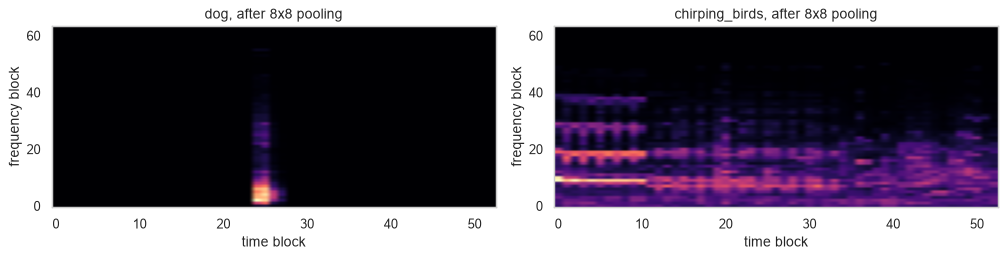

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
for ax, (name, index) in zip(axes, examples.items()):
    ax.imshow(pooling(np.log1p(spectrogram(signals[index])), (8, 8)),
              origin="lower", aspect="auto", cmap="magma")
    ax.set(title=f"{name}, after 8x8 pooling", xlabel="time block", ylabel="frequency block")
    ax.grid(False)
plt.tight_layout()
plt.show()

## Step 4: Flatten into Feature Vectors

Each pooled spectrogram is flattened into one row of the feature matrix. Two normalizations are applied along the way, and both matter:

- **per clip, before the log** — dividing by the maximum removes the recording volume, so a quiet bark and a loud bark look alike;
- **per feature vector, after flattening** — centering and scaling each row puts every clip on the same footing for the distance computation inside spectral clustering.

In [9]:
def build_features(spectra, pool_size=(8, 8)):
    """Normalize, compress and flatten each spectrogram into one feature vector."""
    rows = []
    for spectrum in spectra:
        normalized = np.log1p(spectrum / (spectrum.max() + 1e-12))
        rows.append(pooling(normalized, pool_size).flatten())

    features = np.vstack(rows)
    return (features - features.mean(axis=1, keepdims=True)) / (features.std(axis=1, keepdims=True) + 1e-12)


spectra = [spectrogram(signal) for signal in signals]
X = build_features(spectra, (8, 8))

print(f"Feature matrix: {X.shape} (clips x features)")
print(f"Compression from raw audio: {len(signals[0]) / X.shape[1]:.0f}x fewer numbers per clip")

Feature matrix: (80, 3392) (clips x features)
Compression from raw audio: 65x fewer numbers per clip


In [10]:
def cluster_and_score(features, n_neighbors=10):
    """Spectral clustering with the cluster ids matched to the true classes."""
    labels = SpectralClustering(n_clusters=2, affinity="nearest_neighbors", n_neighbors=n_neighbors,
                                assign_labels="kmeans", random_state=RANDOM_STATE).fit_predict(features)

    overlap = confusion_matrix(y_true, labels)
    class_index, cluster_index = linear_sum_assignment(-overlap)
    aligned = np.array([dict(zip(cluster_index, class_index))[c] for c in labels])
    return labels, aligned


# how much does each normalization step actually contribute?
raw = np.vstack([pooling(np.log1p(spectrum), (8, 8)).flatten() for spectrum in spectra])
per_clip = np.vstack([pooling(np.log1p(spectrum / (spectrum.max() + 1e-12)), (8, 8)).flatten()
                      for spectrum in spectra])
standardize = lambda f: (f - f.mean(axis=1, keepdims=True)) / (f.std(axis=1, keepdims=True) + 1e-12)

ablation = []
for name, features in [
    ("no normalization", raw),
    ("per-clip only", per_clip),
    ("per-vector only", standardize(raw)),
    ("both (used above)", X),
]:
    _, aligned = cluster_and_score(features)
    ablation.append({"normalization": name, "accuracy": accuracy_score(y_true, aligned)})

pd.DataFrame(ablation).round(3)

,normalization,accuracy
0,no normalization,0.662
1,per-clip only,0.950
2,per-vector only,0.950
3,both (used above),0.950


Without any normalization the clustering follows recording loudness as much as the sound source and lands at 66%; either normalization alone is enough to reach 95%. Both are kept, since the combination stays stable across the pooling sizes tried in Step 7.

## Step 5: Spectral Clustering

The same method as in Homework 1: a $k$-nearest-neighbour similarity graph, its Laplacian eigenvectors, and $k$-means in that embedding. Cluster ids are arbitrary, so they are matched to the true classes with the Hungarian algorithm before the confusion matrix is read.

In [11]:
clusters, y_pred = cluster_and_score(X)

matrix = pd.DataFrame(confusion_matrix(y_true, y_pred),
                      index=[f"true {name}" for name in class_names],
                      columns=[f"cluster {name}" for name in class_names])

print(matrix.to_string(), "\n")
print(f"Accuracy:            {accuracy_score(y_true, y_pred):.3f}")
print(f"Adjusted Rand Index: {adjusted_rand_score(y_true, clusters):.3f}")

                     cluster dog  cluster chirping_birds
true dog                      39                       1
true chirping_birds            3                      37 

Accuracy:            0.950
Adjusted Rand Index: 0.808


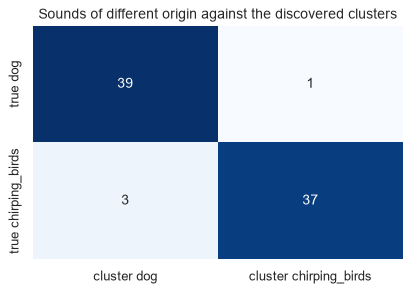

In [12]:
fig, ax = plt.subplots(figsize=(5, 3.6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Sounds of different origin against the discovered clusters")
plt.tight_layout()
plt.show()

## Step 6: What Separates the Clusters

76 of 80 clips are grouped correctly, so the answer to the question posed by the task is yes — sounds of different origin end up in different clusters. The reason is visible in the average spectrum of each class.

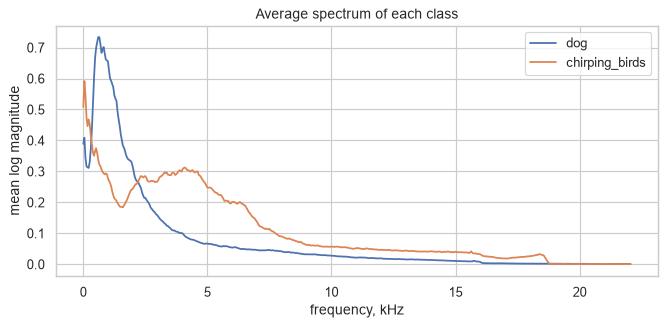

Share of spectral energy per band:
                 dog  chirping_birds
0-1000 Hz      0.325           0.161
1000-4000 Hz   0.442           0.315
4000-22050 Hz  0.233           0.524

Misplaced clips (4):
         filename       category
2-108760-A-14.wav chirping_birds
2-108760-B-14.wav chirping_birds
 2-72547-D-14.wav chirping_birds
   5-9032-A-0.wav            dog


In [13]:
mean_spectra = {
    name: np.mean([np.log1p(spectrum).mean(axis=1) for spectrum, label in zip(spectra, y_true) if label == index], axis=0)
    for index, name in enumerate(class_names)
}

fig, ax = plt.subplots(figsize=(8, 4))
for name, curve in mean_spectra.items():
    ax.plot(frequencies / 1000, curve, label=name)
ax.set(title="Average spectrum of each class", xlabel="frequency, kHz", ylabel="mean log magnitude")
ax.legend()
plt.tight_layout()
plt.show()

bands = [(0, 1000), (1000, 4000), (4000, 22050)]
shares = pd.DataFrame(
    {
        name: [curve[(frequencies >= low) & (frequencies < high)].sum() / curve.sum() for low, high in bands]
        for name, curve in mean_spectra.items()
    },
    index=[f"{low}-{high} Hz" for low, high in bands],
)
print("Share of spectral energy per band:")
print(shares.round(3).to_string())

misclassified = subset.loc[y_pred != y_true, ["filename", "category"]]
print(f"\nMisplaced clips ({len(misclassified)}):")
print(misclassified.to_string(index=False))

## Step 7: How Much Compression Is Useful

Pooling is a lossy compression, so the natural experiment is to vary its strength — from no pooling at all to blocks so large that the spectrogram is reduced to a few dozen numbers — and watch what it does to the clustering.

In [14]:
rows = []
for pool_size in [(1, 1), (2, 2), (4, 4), (8, 8), (16, 16), (32, 32), (64, 64), (128, 128)]:
    features = build_features(spectra, pool_size)
    labels, aligned = cluster_and_score(features)

    rows.append(
        {
            "pooling": f"{pool_size[0]}x{pool_size[1]}",
            "features": features.shape[1],
            "compression": example_spectrogram.size / features.shape[1],
            "ARI": adjusted_rand_score(y_true, labels),
            "accuracy": accuracy_score(y_true, aligned),
        }
    )

compression = pd.DataFrame(rows)
compression.round(3)

,pooling,features,compression,ARI,accuracy
0,1x1,220077,1.000,0.808,0.950
1,2x2,54784,4.017,0.808,0.950
2,4x4,13696,16.069,0.808,0.950
3,8x8,3392,64.881,0.808,0.950
4,16x16,832,264.516,0.596,0.888
5,32x32,208,1058.062,0.557,0.875
6,64x64,48,4584.938,0.268,0.762
7,128x128,12,18339.750,0.024,0.588


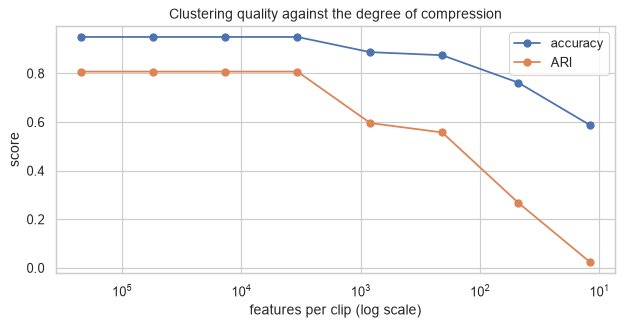

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(compression["features"], compression["accuracy"], marker="o", label="accuracy")
ax.plot(compression["features"], compression["ARI"], marker="o", label="ARI")
ax.set(xscale="log", xlabel="features per clip (log scale)", ylabel="score",
       title="Clustering quality against the degree of compression")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

**The Fourier transform is what makes the task solvable.** In the time domain the two classes are indistinguishable bursts; in the frequency domain they separate cleanly — birds put 52% of their spectral energy above 4 kHz against 23% for dogs, and dogs put twice as much below 1 kHz. Spectral clustering on the resulting features assigns **76 of 80 clips correctly (95%, ARI 0.81)** without any labels.

**Compression is free up to 65×, then it costs.** Accuracy is identical — 95%, ARI 0.81 — from the raw 220 077-value spectrogram all the way down to 3392 features at 8×8 pooling. Past that it falls off: 88.8% at 16×16, 76.2% at 64×64, 58.8% at 128×128, where the frequency axis is too coarse to tell a low band from a high one. So pooling does not improve the clusters here; it buys a 65-fold reduction in size and compute for nothing, which is the point of it.

**Normalization is not optional.** Without it the clustering partly follows recording loudness rather than the sound source and drops to 66%; either normalizing each spectrogram by its own maximum or standardizing each feature vector restores 95%.

**What remains** are the four misplaced clips, which is where a supervised model with proper features (MFCCs, learned filters) would earn its keep — but the pipeline here is entirely unsupervised and built from `np.fft.rfft`, a Hann window and a max-pool.